# 03 — Análisis descriptivo

Estadísticas básicas y correlaciones sobre el panel espacio-temporal
(UPGD × semana epidemiológica) que alimenta el modelo de alerta temprana
de dengue grave en Bucaramanga.

Este notebook **reconstruye el panel exactamente como lo hace `training/train.py`**
(mismos módulos, mismo orden de pasos) hasta el punto justo antes de entrenar el
modelo — así el análisis que sigue describe los datos reales de entrada, no una
muestra aparte. 

In [1]:
import sys
from pathlib import Path
from itertools import product
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

RAIZ_PROYECTO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ_PROYECTO))

from training.data_loader import cargar_datos
from training.preprocessing import preparar_dengue_base
from training.endemic_channel import calcular_canal_endemico
from training.target import crear_target
from training.feature_engineering import crear_features

# Paleta consistente con el resto de artefactos del proyecto (ver dataviz skill / frontend)
AZUL = "#2a78d6"
ROJO = "#e34948"
VERDE = "#0ca30c"
GRIS_TEXTO = "#52514e"
CMAP_DIVERGENTE = LinearSegmentedColormap.from_list("azul_gris_rojo", ["#1c5cab", "#f0efec", "#e34948"])

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#c3c2b7"
plt.rcParams["axes.labelcolor"] = GRIS_TEXTO
plt.rcParams["text.color"] = "#0b0b0b"
plt.rcParams["xtick.color"] = GRIS_TEXTO
plt.rcParams["ytick.color"] = GRIS_TEXTO
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["grid.linewidth"] = 0.6


## 1. Reconstrucción del panel (idéntica a `training/train.py`, pasos 1-5)

In [2]:
os_dir = RAIZ_PROYECTO
df = cargar_datos("03_primary/dataset_limpio.xlsx")

casos_upgd, df_clima, todas_upgds = preparar_dengue_base(df)
todas_semanas = df_clima[["año_ini_sin", "semana_epi_ini_sin"]].drop_duplicates()

esqueleto = pd.DataFrame(
    list(product(todas_semanas.itertuples(index=False), todas_upgds)),
    columns=["semana_combo", "nom_upgd"],
)
esqueleto[["año_ini_sin", "semana_epi_ini_sin"]] = pd.DataFrame(
    esqueleto["semana_combo"].tolist(), index=esqueleto.index
)
esqueleto = esqueleto.drop(columns=["semana_combo"])

panel_maestro = esqueleto.merge(
    casos_upgd, on=["año_ini_sin", "semana_epi_ini_sin", "nom_upgd"], how="left"
)
panel_maestro["casos"] = panel_maestro["casos"].fillna(0).astype(int)
del esqueleto, casos_upgd, df
gc.collect()

panel_maestro = calcular_canal_endemico(panel_maestro)
panel_maestro = crear_target(panel_maestro)
panel_maestro = crear_features(panel_maestro, df_clima)

panel = panel_maestro.dropna(
    subset=["target_intervencion", "casos_lag_52", "media_casos_4"]
).reset_index(drop=True)
panel["target_intervencion"] = panel["target_intervencion"].astype(int)

print(f"Panel final: {panel.shape[0]:,} filas (UPGD-semana) x {panel.shape[1]} columnas")
print(f"UPGDs distintas: {panel['nom_upgd'].nunique()}")
print(f"Rango temporal: {panel['año_ini_sin'].min()}–{panel['año_ini_sin'].max()}")


Panel final: 7,327 filas (UPGD-semana) x 153 columnas
UPGDs distintas: 17
Rango temporal: 2010–2024


## 2. Estadísticas básicas

In [3]:
print("Valores nulos por columna (solo columnas con nulos, si hay):")
nulos = panel.isna().sum()
nulos = nulos[nulos > 0].sort_values(ascending=False)
print(nulos if len(nulos) else "  (ninguno — el panel quedó completo tras el dropna del pipeline)")


Valores nulos por columna (solo columnas con nulos, si hay):
  (ninguno — el panel quedó completo tras el dropna del pipeline)


In [5]:
variables_clave = [
    "casos", "target_intervencion", "persistencia_alerta_8", "persistencia_alerta_4",
    "alerta_lag_1", "media_casos_4", "std_casos_4", "vecinos_alerta_prom",
    "precipitacion_total", "precipitacion_total_rollmean4",
    "temperatura_media", "temperatura_min", "temperatura_max",
]
variables_clave = [v for v in variables_clave if v in panel.columns]
panel[variables_clave].describe().T


,count,mean,std,min,25%,50%,75%,max
casos,7327.0,1.181111,2.380897,0.0,0.000000,0.000000,1.000000,39.000000
target_intervencion,7327.0,0.258087,0.437612,0.0,0.000000,0.000000,1.000000,1.000000
persistencia_alerta_8,7327.0,1.321141,2.229997,0.0,0.000000,0.000000,2.000000,8.000000
persistencia_alerta_4,7327.0,0.670124,1.194427,0.0,0.000000,0.000000,1.000000,4.000000
alerta_lag_1,7327.0,0.169101,0.374866,0.0,0.000000,0.000000,0.000000,1.000000
media_casos_4,7327.0,1.167633,2.084358,0.0,0.000000,0.250000,1.500000,33.500000
std_casos_4,7327.0,0.755177,1.028280,0.0,0.000000,0.500000,1.000000,13.976171
vecinos_alerta_prom,7327.0,0.144625,0.242387,0.0,0.000000,0.000000,0.333333,1.000000
precipitacion_total,7327.0,11.816557,17.555571,0.0,1.512000,5.400000,13.500000,99.876999
precipitacion_total_rollmean4,7327.0,11.917837,11.358582,0.0,3.550000,7.125000,18.225000,56.700001


In [7]:
tasa_intervencion = panel["target_intervencion"].mean()
print(f"Tasa global de intervención (clase positiva): {tasa_intervencion:.1%}")
print(f"Semanas UPGD sin intervención: {(panel['target_intervencion']==0).sum():,}")
print(f"Semanas UPGD con intervención:  {(panel['target_intervencion']==1).sum():,}")


Tasa global de intervención (clase positiva): 25.8%
Semanas UPGD sin intervención: 5,436
Semanas UPGD con intervención:  1,891


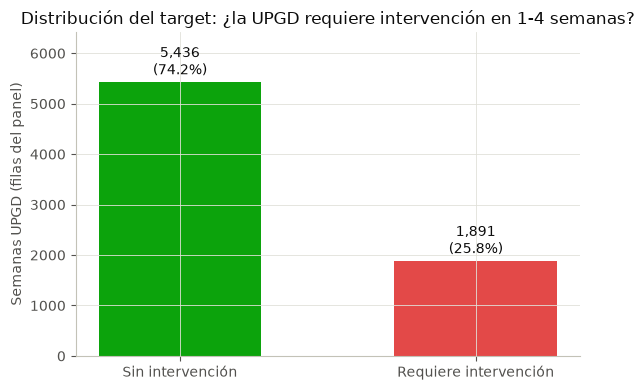

In [8]:
conteo = panel["target_intervencion"].value_counts().sort_index()
etiquetas = ["Sin intervención", "Requiere intervención"]
colores = [VERDE, ROJO]

fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(etiquetas, conteo.values, color=colores, width=0.55)
for barra, valor in zip(barras, conteo.values):
    ax.text(barra.get_x() + barra.get_width()/2, valor + conteo.max()*0.01,
            f"{valor:,}\n({valor/conteo.sum():.1%})", ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Semanas UPGD (filas del panel)")
ax.set_title("Distribución del target: ¿la UPGD requiere intervención en 1-4 semanas?")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, conteo.max()*1.18)
plt.tight_layout()
plt.show()


## 3. Serie de tiempo: casos totales por semana

Suma de casos de las 17 UPGDs por semana epidemiológica, para ver la
estacionalidad del dengue en Bucaramanga a lo largo de los años del panel.


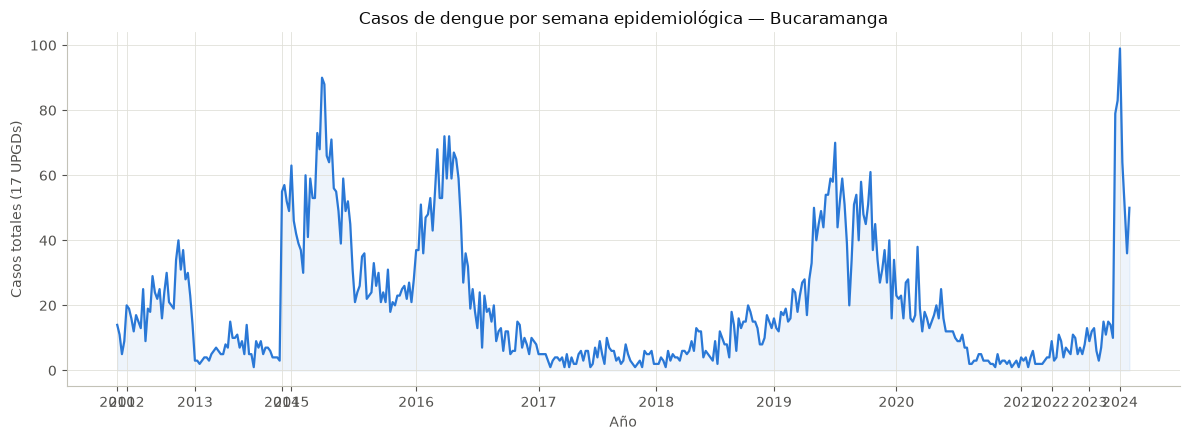

In [9]:
casos_semana = (
    panel.groupby(["año_ini_sin", "semana_epi_ini_sin"])["casos"]
    .sum()
    .reset_index()
    .sort_values(["año_ini_sin", "semana_epi_ini_sin"])
)
casos_semana["indice_tiempo"] = range(len(casos_semana))

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(casos_semana["indice_tiempo"], casos_semana["casos"], color=AZUL, linewidth=1.6)
ax.fill_between(casos_semana["indice_tiempo"], casos_semana["casos"], color=AZUL, alpha=0.08)

# Marcas de año en el eje x (una por cada primer registro del año)
marcas = casos_semana.groupby("año_ini_sin")["indice_tiempo"].min()
ax.set_xticks(marcas.values)
ax.set_xticklabels(marcas.index.astype(int), rotation=0)

ax.set_ylabel("Casos totales (17 UPGDs)")
ax.set_xlabel("Año")
ax.set_title("Casos de dengue por semana epidemiológica — Bucaramanga")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 4. Casos totales por UPGD (todo el histórico)

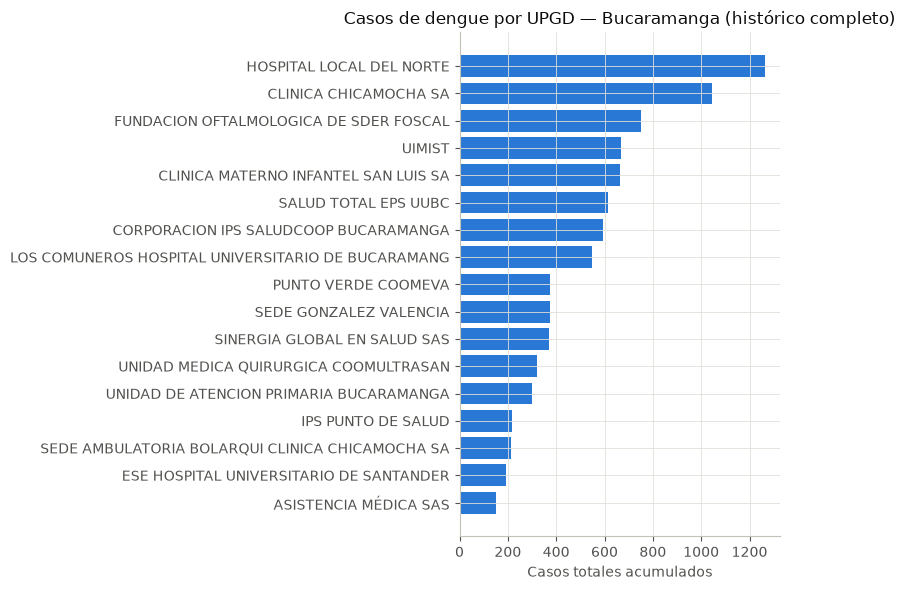

In [10]:
casos_por_upgd = (
    panel.groupby("nom_upgd")["casos"].sum().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(casos_por_upgd.index[::-1], casos_por_upgd.values[::-1], color=AZUL)
ax.set_xlabel("Casos totales acumulados")
ax.set_title("Casos de dengue por UPGD — Bucaramanga (histórico completo)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 5. Correlaciones

### 5.1 Matriz de correlación — variables clave

Un subconjunto legible de ~20 variables (de las 142 del modelo): el target,
las variables autoregresivas de momentum epidémico, el contagio espacial y
el clima crudo. La matriz completa de 142×142 no es interpretable visualmente;
este subconjunto es el que aparece consistentemente en el top de importancia
SHAP (ver `scripts/shap_summary.png` y `BITACORA_EXPERIMENTOS.txt`).


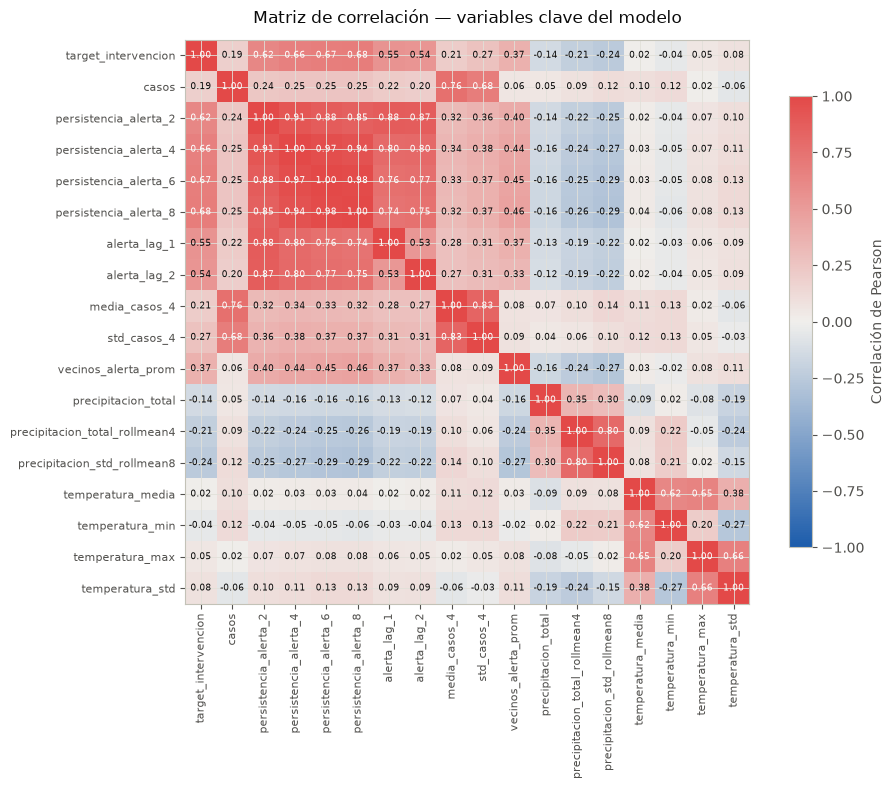

In [11]:
subset_corr = [
    "target_intervencion", "casos",
    "persistencia_alerta_2", "persistencia_alerta_4", "persistencia_alerta_6", "persistencia_alerta_8",
    "alerta_lag_1", "alerta_lag_2", "media_casos_4", "std_casos_4",
    "vecinos_alerta_prom",
    "precipitacion_total", "precipitacion_total_rollmean4", "precipitacion_std_rollmean8",
    "temperatura_media", "temperatura_min", "temperatura_max", "temperatura_std",
]
subset_corr = [v for v in subset_corr if v in panel.columns]
corr = panel[subset_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap=CMAP_DIVERGENTE, vmin=-1, vmax=1)
ax.set_xticks(range(len(subset_corr)))
ax.set_xticklabels(subset_corr, rotation=90, fontsize=8)
ax.set_yticks(range(len(subset_corr)))
ax.set_yticklabels(subset_corr, fontsize=8)

for i in range(len(subset_corr)):
    for j in range(len(subset_corr)):
        valor = corr.values[i, j]
        color_texto = "white" if abs(valor) > 0.6 else "#0b0b0b"
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=6.5, color=color_texto)

cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Correlación de Pearson")
ax.set_title("Matriz de correlación — variables clave del modelo", pad=12)
plt.tight_layout()
plt.show()


### 5.2 Correlación de cada variable con el target (`target_intervencion`)

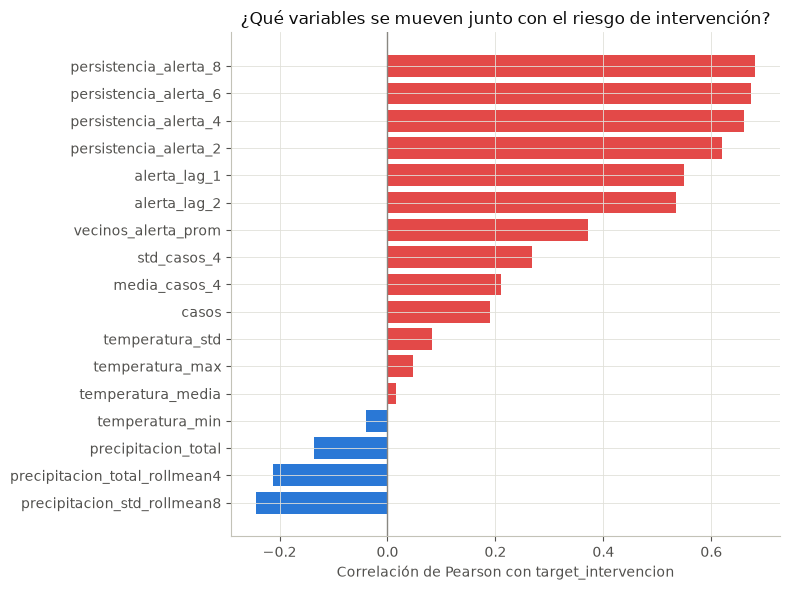

In [12]:
corr_target = (
    panel[subset_corr].corr()["target_intervencion"]
    .drop("target_intervencion")
    .sort_values()
)
colores_barra = [ROJO if v > 0 else AZUL for v in corr_target.values]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(corr_target.index, corr_target.values, color=colores_barra)
ax.axvline(0, color="#898781", linewidth=1)
ax.set_xlabel("Correlación de Pearson con target_intervencion")
ax.set_title("¿Qué variables se mueven junto con el riesgo de intervención?")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


## 6. Conclusiones

- La tasa de intervención global (~26% de las filas UPGD-semana) confirma que el
  problema está razonablemente balanceado para un target de alerta temprana —
  ni tan raro que el modelo no tenga señal positiva suficiente, ni tan frecuente
  que "siempre alertar" sea una estrategia trivial.
- Los `persistencia_alerta_*` (momentum epidémico: cuántas de las últimas N
  semanas la UPGD estuvo en alerta) son, de lejos, las variables más
  correlacionadas con el target — consistente con el hallazgo SHAP documentado
  en `docs/conclusiones.md` (hallazgo 3): el modelo se apoya principalmente en
  inercia epidémica real, no solo en clima crudo.
- Las variables climáticas (`precipitacion_*`, `temperatura_*`) muestran
  correlaciones más modestas (0.10-0.25) de forma individual — coherente con el
  análisis CCF documentado en `BITACORA_EXPERIMENTOS.txt` (experimento 8): el
  clima aporta señal real pero rezagada y relativamente débil comparada con la
  persistencia epidémica.
- La serie de casos por semana muestra estacionalidad marcada, con picos que
  varían de año a año — justamente el patrón que el canal endémico
  (`endemic_channel.py`) usa como referencia histórica para detectar brotes.

Estas observaciones son puramente descriptivas: la validación real de que el
modelo aprovecha esta señal (y no solo memoriza identidad de UPGD) está en las
ablaciones y el baseline ingenuo documentados en `BITACORA_EXPERIMENTOS.txt`.
